# Функция активации softmax и функции потерь для классификации


План документа:
1. Как решать задачу многоклассовой классификации с помощью keras
2. Когда использовать sigmoid, когда softmax
3. Как решать задачу мультилейбл классификации с помощью keras и sklearn
4. Когда использовать binary_crossentropy, а когда categorical_crossentropy

## Установка нужных версий библиотек

In [ ]:
#@title установка
!wget 'https://drive.google.com/uc?id=16QGru39Yn51aKOpZ8UdqZvxWqlbm78D8' -O requirements.txt
!pip install -r requirements.txt

--2024-12-11 11:22:22--  https://drive.google.com/uc?id=16QGru39Yn51aKOpZ8UdqZvxWqlbm78D8
Resolving drive.google.com (drive.google.com)... 74.125.69.101, 74.125.69.113, 74.125.69.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.69.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=16QGru39Yn51aKOpZ8UdqZvxWqlbm78D8 [following]
--2024-12-11 11:22:23--  https://drive.usercontent.google.com/download?id=16QGru39Yn51aKOpZ8UdqZvxWqlbm78D8
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.69.132, 2607:f8b0:4001:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353 [application/octet-stream]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]     353  --.-KB/s    in 0s      

2024-12-11 11:22:25 (13.2 MB/s) - ‘requirement

## Мультикласс на изображениях

Подгрузим данные из стандартных датасетов из `keras`.

Датасет называется MNIST и представляет из себя черно-белые изображения 28 на 28 пикселей.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, X_test.shape

11490434/11490434 [==============================] - 1s 0us/step


((60000, 28, 28), (10000, 28, 28))

In [ ]:
X_train[0].shape

(28, 28)

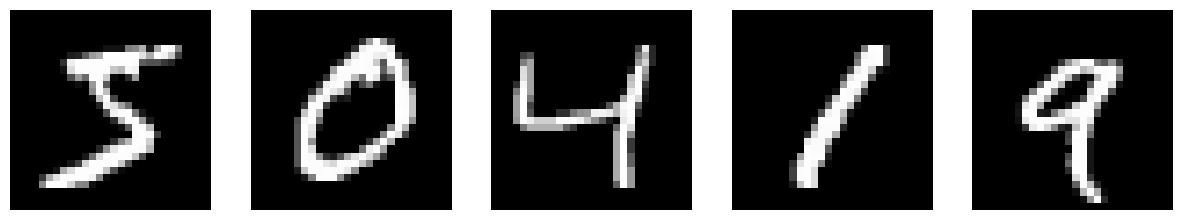

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')

In [ ]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

На предыдущих видео упрощали задачу и брали для обучения только два класса, чтобы сделать задачу бинарной классификации.

Сейчас же возьмём все 10 классов.

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Нормируем данные, воспользуемся делением на 255, т.к. сейчас изображения представлены пикселями в диапазоне от 0 до 255, а для нейросети комфортней обучаться на диапазоне от 0 до 1.

In [ ]:
print(X_train.min(), X_train.max())

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())

0 255
0.0 1.0


Так же нужно видоизменить метку класса, сейчас это лейблы 0 или 1, нужно преобразовать в бинарный вид.

Тем самым получаем 2 столбика, где первый - это метка является ли изображение 0 классом, а второй столбик - является ли изображение 1 классом.

In [ ]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [ ]:
y_train_cat[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

В предыдущих видео, чтобы легче обучать сетку меняли масштаб изображений на 6x6.

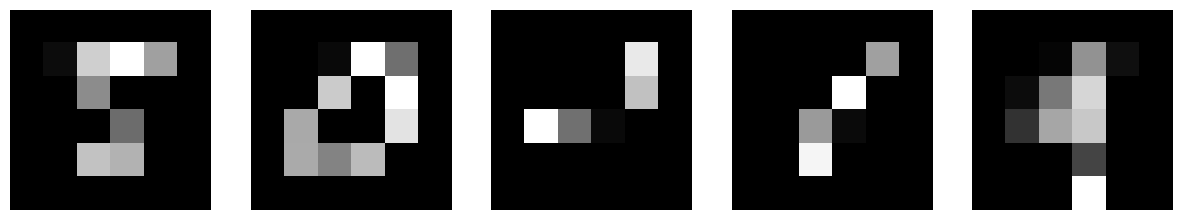

In [ ]:
X_train_resized = tf.image.resize(X_train[..., np.newaxis], (6, 6))[..., 0]
X_test_resized = tf.image.resize(X_test[..., np.newaxis], (6, 6))[..., 0]

fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train_resized[i], cmap='gray')
    ax[i].axis('off')

In [ ]:
X_train_resized[..., np.newaxis].shape

TensorShape([60000, 6, 6, 1])

В этом видео так делать не будем, оставим изображения 28x28.

### Создание сети

Во-первых, на вход поступает изображение 28х28, нужно с ним что-то сделать, так как наша сетку пока не умеет работать с двумерным входом. Здесь нам поможет слой из `keras` `Flatten`, который вытягивает изображение в один вектор, была картинка 6x6, а станет вектором с размерностью 784.

In [ ]:
28 * 28

784

Будем пользоваться функциональным созданием нейронной сети. Для начала создаем слой `Input`, которые будет определять размер входных данных.

In [ ]:
from keras.layers import Input

input = Input(shape=(X_train.shape[1:]))
input

<KerasTensor: shape=(None, 28, 28) dtype=float32 (created by layer 'input_1')>

Затем создаем слой `Flatten`, для вытягивания двумерного изображения в одномерное.

In [ ]:
from keras.layers import Flatten, Dense

flatten = Flatten()(input)
flatten

<KerasTensor: shape=(None, 784) dtype=float32 (created by layer 'flatten')>

И остается объединить ранее определенные слои в модель в объекте `Model`. Здесь мы можем протестировать вытягивание изображения в одномерный вектор.

In [ ]:
from keras.models import Model

flattenizer = Model(inputs=input, outputs=flatten)
flattenizer.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Можем протестировать изменение изображения.

In [ ]:
flatten_img = flattenizer(X_train[:1])
flatten_img.shape

TensorShape([1, 784])

Во-вторых, на выходе не что-то одно, а десять вероятностей быть определенным классом.

А значит на выходе имеем десять нейронов, каждый из которых отвечает за класс.

In [ ]:
from keras.layers import Dense
tf.random.set_seed(9)

output = Dense(10)(flatten)
output

<KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'dense')>

В-третьих, на изображении может быть только один класс, не может быть такого, что на картинке есть 9 и 3, есть либо 9, либо 3. Поэтому использовать функцию активации sigmoid на выходе не вариант. Сейчас посмотрим почему.


Добавим сигмоиду на выходе и соединим всё создание сети в одной ячейке.

In [ ]:
from keras.models import Model
tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
output = Dense(10, activation='sigmoid')(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Скомпилируем сеть. Функция потерь не `binary_crossentropy`, а `categorical_crossentropy`, т.к. уже не два класса, а больше.

In [ ]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics='accuracy'
)

Обучим сеть.

In [ ]:
model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 [==============================] - 20s 6ms/step - loss: 0.7799 - accuracy: 0.8148 - val_loss: 0.4805 - val_accuracy: 0.8803
Epoch 2/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4576 - accuracy: 0.8784 - val_loss: 0.4001 - val_accuracy: 0.8943
Epoch 3/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4041 - accuracy: 0.8904 - val_loss: 0.3678 - val_accuracy: 0.9003
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3773 - accuracy: 0.8965 - val_loss: 0.3478 - val_accuracy: 0.9050
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3604 - accuracy: 0.9000 - val_loss: 0.3349 - val_accuracy: 0.9088


Теперь сделаем предсказания вероятностей.

In [ ]:
probas = model.predict(X_test[:1])
probas

1/1 [==============================] - 0s 299ms/step


array([[0.3435568 , 0.00360319, 0.37803417, 0.8318897 , 0.13272353,
        0.20137738, 0.0076236 , 0.9996765 , 0.36157376, 0.8850208 ]],
      dtype=float32)

Видим, что есть несколько больших вероятностей, скорее всего объект либо 9, либо 7 класс.

Функция активации сигмоида может изменяться от 0 до 1 для каждого нейрона.

<img src='https://drive.google.com/uc?id=1xJsLuIB-BM-hX4Dew2egznextyMxAjGI' width=600>

### Softmax

Но если будем использовать другую функцию активации - Softmax.

<img src='https://drive.google.com/uc?export=view&id=1dW-Hk-qogTWG-x3bkzlM5aHsWhxe3juX'>

Уберем функцию активации сигмоиду и заново обучим модель.

In [ ]:
tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
output = Dense(10)(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics='accuracy'
)

model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 [==============================] - 11s 6ms/step - loss: 3.4547 - accuracy: 0.1024 - val_loss: 2.9440 - val_accuracy: 0.1098
Epoch 2/5
1875/1875 [==============================] - 11s 6ms/step - loss: 8.0297 - accuracy: 0.1134 - val_loss: 7.4187 - val_accuracy: 0.1107
Epoch 3/5
1875/1875 [==============================] - 11s 6ms/step - loss: 7.0474 - accuracy: 0.1133 - val_loss: 7.6185 - val_accuracy: 0.1133
Epoch 4/5
1875/1875 [==============================] - 12s 6ms/step - loss: 7.3654 - accuracy: 0.1130 - val_loss: 7.9072 - val_accuracy: 0.1151
Epoch 5/5
1875/1875 [==============================] - 11s 6ms/step - loss: 7.9267 - accuracy: 0.1179 - val_loss: 8.2713 - val_accuracy: 0.1161


Кстати видим, что модель обучается не очень хорошо в сравнении с предыдущей сетью. Можем это исправить

In [ ]:
tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
output = Dense(10)(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Так вышло из-за того, что категорийная кросс-энтропия по умолчанию считает ошибку на вероятностях, но у нас в сети возвращаются логиты, а не вероятности.

In [ ]:
from keras import losses

model.compile(
    optimizer='sgd',
    loss=losses.CategoricalCrossentropy(from_logits=True),
    metrics='accuracy'
)

model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 [==============================] - 14s 6ms/step - loss: 0.7890 - accuracy: 0.8095 - val_loss: 0.4843 - val_accuracy: 0.8795
Epoch 2/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4590 - accuracy: 0.8797 - val_loss: 0.4025 - val_accuracy: 0.8961
Epoch 3/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4050 - accuracy: 0.8904 - val_loss: 0.3697 - val_accuracy: 0.9010
Epoch 4/5
1875/1875 [==============================] - 8s 5ms/step - loss: 0.3780 - accuracy: 0.8967 - val_loss: 0.3497 - val_accuracy: 0.9052
Epoch 5/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3610 - accuracy: 0.9005 - val_loss: 0.3366 - val_accuracy: 0.9085


Теперь сеть обучается гораздо лучше

In [ ]:
logits = model.predict(X_test[:1])
logits

1/1 [==============================] - 1s 851ms/step


array([[-0.03091706, -5.5287266 , -0.2230571 ,  1.7888557 , -1.794339  ,
        -1.3645446 , -4.536444  ,  8.244915  , -0.2786816 ,  2.1412187 ]],
      dtype=float32)

Можем вручную посчитать значения выхода после Softmax функции активации

In [ ]:
np.exp(logits) / np.sum(np.exp(logits))

array([[2.5343450e-04, 1.0380002e-06, 2.0913196e-04, 1.5638066e-03,
        4.3453161e-05, 6.6784953e-05, 2.7998849e-06, 9.9543738e-01,
        1.9781671e-04, 2.2243971e-03]], dtype=float32)

In [ ]:
(np.exp(logits) / np.sum(np.exp(logits))).sum()

1.0

Или же воспользоваться классом Softmax в keras

In [ ]:
from keras.layers import Softmax

softmax = Softmax()
probas = softmax(logits)
probas

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[2.5343447e-04, 1.0380001e-06, 2.0913201e-04, 1.5638062e-03,
        4.3453147e-05, 6.6784938e-05, 2.7998863e-06, 9.9543732e-01,
        1.9781667e-04, 2.2243969e-03]], dtype=float32)>

In [ ]:
np.sum(probas)

0.99999994

In [ ]:
np.argmax(probas)

7

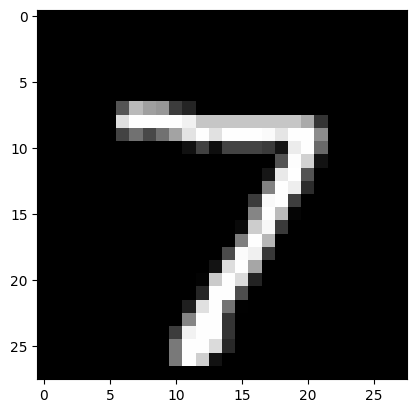

In [ ]:
plt.imshow(X_test[0], cmap='gray');

И проверимся на всех обучающих данных.

Делаем предсказания на всех тестовых объектах.

In [ ]:
preds = model.predict(X_test)
preds.shape

313/313 [==============================] - 0s 1ms/step


(10000, 10)

И берем метку класса, где максимальная вероятность.

In [ ]:
preds_cls = preds.argmax(axis=1)
preds_cls

array([7, 2, 1, ..., 4, 5, 6])

И можем посчитать метрику качества.

In [ ]:
from sklearn.metrics import accuracy_score

print(f'test acc: {accuracy_score(y_test, preds_cls)*100:.2f}% ({(y_test == preds_cls).sum()} out of {y_test.shape[0]})')

test acc: 90.85% (9085 out of 10000)


Или же сразу можно добавить Softmax в саму сеть. Кстати можем отдельно добавлять слои с функциями активаций.

In [ ]:
tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
dense = Dense(10)(flatten)
output = Softmax()(dense)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 10)                7850      
                                                                 
 softmax_1 (Softmax)         (None, 10)                0         
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(
    optimizer='sgd',
    loss=losses.CategoricalCrossentropy(from_logits=False),
    metrics='accuracy'
)

model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 [==============================] - 15s 8ms/step - loss: 0.7783 - accuracy: 0.8155 - val_loss: 0.4786 - val_accuracy: 0.8802
Epoch 2/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4565 - accuracy: 0.8800 - val_loss: 0.3996 - val_accuracy: 0.8935
Epoch 3/5
1875/1875 [==============================] - 11s 6ms/step - loss: 0.4037 - accuracy: 0.8905 - val_loss: 0.3677 - val_accuracy: 0.9008
Epoch 4/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3772 - accuracy: 0.8974 - val_loss: 0.3481 - val_accuracy: 0.9051
Epoch 5/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.3605 - accuracy: 0.9008 - val_loss: 0.3354 - val_accuracy: 0.9081


In [ ]:
preds = model.predict(X_test)
preds_cls = preds.argmax(axis=1)

print(f'test acc: {accuracy_score(y_test, preds_cls)*100:.2f}% ({(y_test == preds_cls).sum()} out of {y_test.shape[0]})')

313/313 [==============================] - 1s 2ms/step
test acc: 90.81% (9081 out of 10000)


Теперь  не будет такого, что с равной вероятностью у нас картинке 5 класс и 2, к примеру, а будет только один класс с максимальной вероятностью благодаря Softmax.

### Пример работы сети

Можем посмотреть на пару классификаций

In [ ]:
def plot_image(preds, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap='gray')

    predicted_label = np.argmax(preds)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel(f"{predicted_label}\n" \
               f"{100*np.max(preds):2.0f}% " \
               f"({true_label})",
               color=color)

def plot_value_array(preds, true_label):
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), preds, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(preds)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

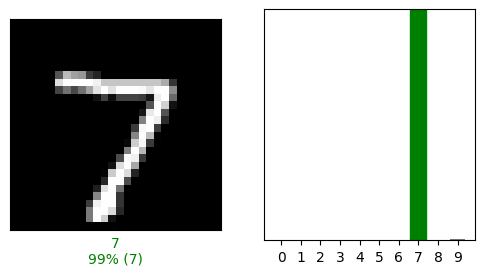

In [ ]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(preds[i], y_test[i], X_test[i])
plt.subplot(1,2,2)
plot_value_array(preds[i], y_test[i])
plt.show()

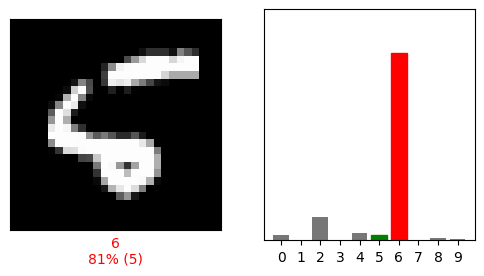

In [ ]:
i = 8
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(preds[i], y_test[i], X_test[i])
plt.subplot(1,2,2)
plot_value_array(preds[i], y_test[i])
plt.show()

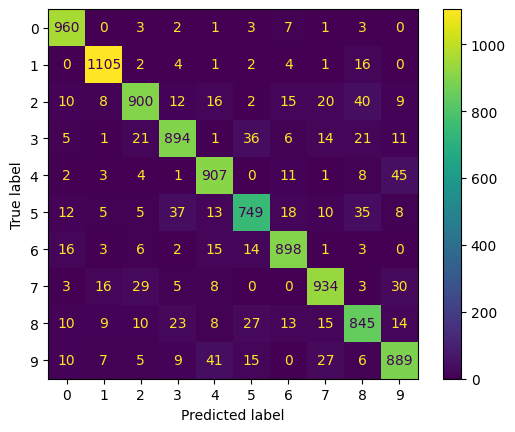

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds_cls, labels=np.arange(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot();